# GNAV pipeline application on VTTI dataset

With a satellite reference image, we intend to utilize a SfM solution to match ground segments of images to the reference map.
- Inputs: Reference image (satellite), SfM solution (images, points, cameras), selected images (5)
- Output: Correction solutions for translation, rotation, scaling

APPLYING ORIGINAL PIPELINE ON VTTI AIRPORT

In [28]:
import numpy as np
import cv2
import open3d as o3d
import plotly.graph_objects as go
import plotly.io as pio
from scipy.spatial.transform import Rotation as R
from scipy.spatial import cKDTree
import imageio
import pickle
# %matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.path import Path
import time
from scipy.stats import norm, multivariate_normal

from groundNAV_agent_VTTI import *
from colmapParsingUtils import *
from microp_distb_VTTI import *
from distb_plotting_utils_VTTI import *
import pycolmap

# SAVE YOUR WORK
%load_ext autoreload
%autoreload 2
%autosave 180

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Autosaving every 180 seconds


In [29]:
# UPLOAD INPUTS

# CLOSER IMAGES 
# Load in necessary parameters for gNAV agent 
# Define Class Parameters 

images_colm  = "VTTI_data/HIGH/images.txt"
cameras_colm = "VTTI_data/HIGH/cameras.txt"
pts3d_colm = "VTTI_data/HIGH/points3D.txt"

# Local images - folder
im_local = 'VTTI_data/test_images_feb17_2026/' # With 10 local images 


# Load in satellite reference image
sat_ref = "VTTI_data/Satellite/KBCB_partial.jpg" # UPDATED VERSION - ZOOMED IN

In [30]:
# Create class
gnav = gNAV_agent(images_colm, cameras_colm, pts3d_colm, im_local, sat_ref)

# Status check 
# print(gnav.pts3d_c.items)

# Grab raw points and RGB data for scene and reference cloud
scene_pts, rgb_data = gnav.scene_pts, gnav.scene_rgb
ref_pts, ref_rgb = gnav.ref_pts, gnav.ref_rgb

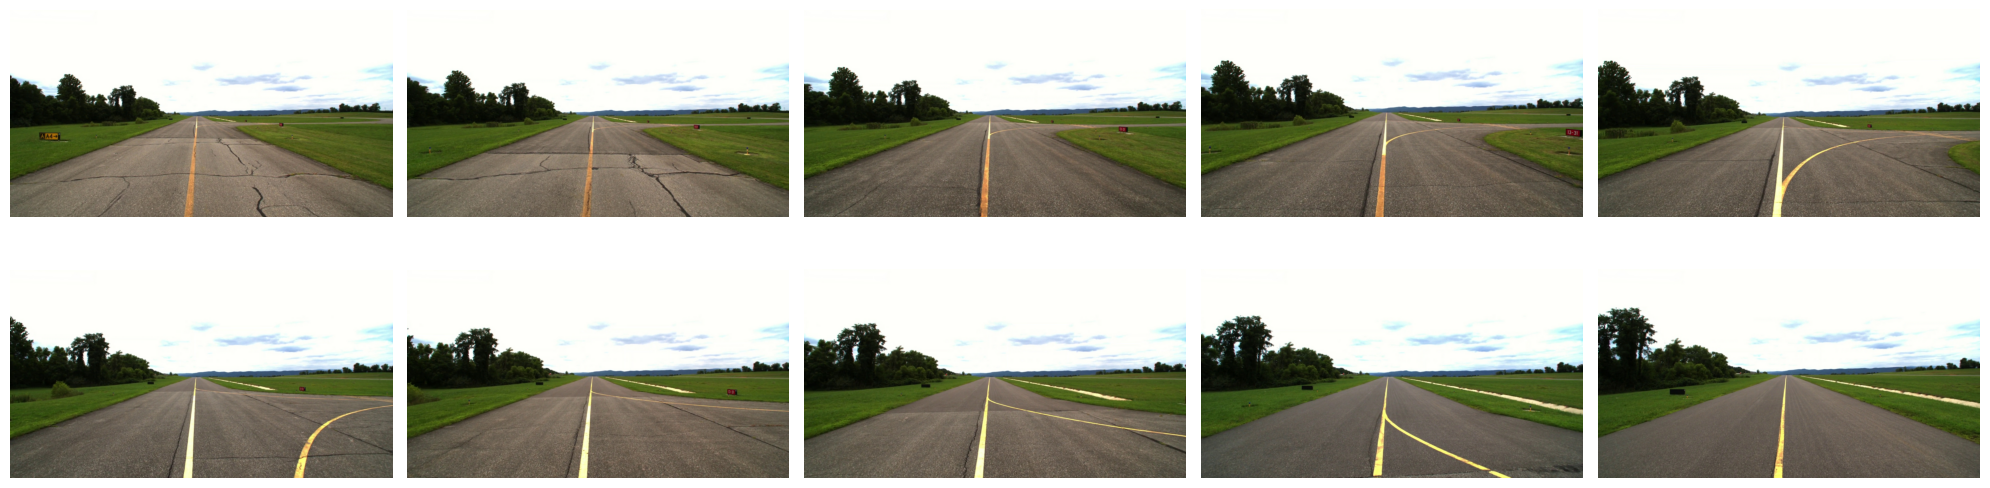

In [31]:
n_imgs = len(gnav.images_dict)
ncols = 5
nrows = math.ceil(n_imgs / ncols)

# Scale figure size: tweak these if you want bigger/smaller
fig_w = 4 * ncols
fig_h = 3 * nrows

plt.figure(figsize=(fig_w, fig_h))

for imnum in range(n_imgs):
    ax = plt.subplot(nrows, ncols, imnum + 1)

    im = gnav.images_dict[imnum]
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

    ax.imshow(im)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [32]:
# GET POSES 
gnav.grab_poses(gnav.images_c)

In [33]:
# Plot the initial scene
# PLOT INITIAL POINT CLOUD AND POSES 
# PLOT GROUND PLANE PTS (if desired)

# Ground plane point indices (retrieved through pos file)
# New ground plane points: (see <VTTI_pos_vis_high.ipynb> for old points
pts_gnd_idx = np.load("gnd_idx_VTTI_high.npy")
pts_gnd = gnav.scene_pts[pts_gnd_idx]

# Create Open3D visualizer object
vis = o3d.visualization.Visualizer()
vis.create_window(window_name='3D Plot with Pose Axes and Point Cloud')

# Add coordinate axes
axes = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1)

# Add each pose estimate frame 
for p in gnav.poses:
    axes = o3d.geometry.TriangleMesh.create_coordinate_frame(size=.25).transform(p)
    vis.add_geometry(axes)


# Colmap sparse cloud
scene_cloud = o3d.geometry.PointCloud()
scene_cloud.points = o3d.utility.Vector3dVector(scene_pts)
scene_cloud.colors = o3d.utility.Vector3dVector(rgb_data)

# Reference satellite image 
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(ref_rgb)

# Ground points test 
gnd_cloud = o3d.geometry.PointCloud()
gnd_cloud.points = o3d.utility.Vector3dVector(pts_gnd)
gnd_cloud.paint_uniform_color([1.0,0,0])



vis.add_geometry(axes)
vis.add_geometry(scene_cloud)
# vis.add_geometry(ref_cloud)
# vis.add_geometry(gnd_cloud)

# # Size options (jupyter gives issues when running this multiple times, but it looks better)
# render_option = vis.get_render_option()
# render_option.point_size = 1.5


# Run the visualizer
vis.run()
vis.destroy_window()

## Set Reference Frame to Middle

In [34]:
print(len(scene_pts))

17302


In [35]:
pts_gnd_idx = np.load("gnd_idx_VTTI_high.npy")
tform_ref_frame = gnav.set_ref_frame(pts_gnd_idx) # ALTER FOR KBCB SPECIFIC
tform_ref_frame_pts = gnav.inv_homog_transform(tform_ref_frame)
print("\nReference frame transformation\n", tform_ref_frame_pts)


Reference frame transformation
 [[ 0.51431895 -0.03090211  0.85704205  0.17398593]
 [ 0.85758321  0.02459256 -0.51375698  0.22011112]
 [-0.00520069  0.99921983  0.03914955  0.90655603]
 [ 0.          0.          0.          1.        ]]


In [36]:
# Transform all points to the new coordinate system 
# Not necessary since we aren't using the cloud, but a good visual check for coord frame
tform_ref_frame_inv = gnav.inv_homog_transform(tform_ref_frame)
origin_ref, scene_pts_ref, scene_vec_ref = gnav.unit_vec_tform(scene_pts, gnav.origin_w, tform_ref_frame_inv)
# print(origin_ref)

In [37]:
# # Plot the initial scene
# # PLOT INITIAL POINT CLOUD AND POSES 
# # Create Open3D visualizer object
# vis = o3d.visualization.Visualizer()
# vis.create_window(window_name='3D Plot with Pose Axes and Point Cloud')

# # Add coordinate axes
# axes = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1)
    
# scene_cloud = o3d.geometry.PointCloud()
# scene_cloud.points = o3d.utility.Vector3dVector(scene_pts_ref)
# scene_cloud.colors = o3d.utility.Vector3dVector(rgb_data)


# ref_cloud = o3d.geometry.PointCloud()
# ref_cloud.points = o3d.utility.Vector3dVector(ref_pts)
# ref_cloud.colors = o3d.utility.Vector3dVector(ref_rgb)

# vis.add_geometry(axes)
# vis.add_geometry(scene_cloud)
# vis.add_geometry(ref_cloud)

# # # Size options (jupyter gives issues when running this multiple times, but it looks better)
# # render_option = vis.get_render_option()
# # render_option.point_size = 1.5


# # Run the visualizer
# vis.run()
# vis.destroy_window()

In [38]:
# # Image 0 
# imnum = 0
# x,y = 700,600
# side_x = 400 # WIDTH
# side_y = 250 # HEIGHT

# # Plot to visualize
# gnav.plot_rect_im(x, y, side_x, side_y, imnum) 

# # Get necessary location and rgb data 
# gnav.grab_image_pts(x, y, side_x, side_y, imnum)
# # print(pts_loc)
# # print(pts_rgb)

In [39]:
# # Image 1 
# imnum = 1
# x,y = 700,550
# side_x = 400 # WIDTH
# side_y = 200 # HEIGHT

# # Plot to visualize
# gnav.plot_rect_im(x, y, side_x, side_y, imnum) 

# # Get necessary location and rgb data 
# gnav.grab_image_pts(x, y, side_x, side_y, imnum)
# # print(pts_loc)
# # print(pts_rgb)

In [40]:
# # Image 2
# imnum = 2
# x,y = 700,550
# side_x = 300 # WIDTH
# side_y = 200 # HEIGHT

# # Plot to visualize
# gnav.plot_rect_im(x, y, side_x, side_y, imnum) 

# # Get necessary location and rgb data 
# gnav.grab_image_pts(x, y, side_x, side_y, imnum)
# # print(pts_loc)
# # print(pts_rgb)

In [41]:
# # Image 3
# imnum = 3
# x,y = 700,525
# side_x = 300 # WIDTH
# side_y = 175 # HEIGHT

# # Plot to visualize
# gnav.plot_rect_im(x, y, side_x, side_y, imnum) 

# # Get necessary location and rgb data 
# gnav.grab_image_pts(x, y, side_x, side_y, imnum)
# # print(pts_loc)
# # print(pts_rgb)

In [42]:
# # Image 4
# imnum = 4
# x,y = 700,600
# side_x = 300 # WIDTH
# side_y = 200 # HEIGHT

# # Plot to visualize
# gnav.plot_rect_im(x, y, side_x, side_y, imnum) 
# # Get necessary location and rgb data 
# gnav.grab_image_pts(x, y, side_x, side_y, imnum)
# # print(pts_loc)
# # print(pts_rgb)

In [43]:
# # Image 5
# imnum = 5
# x,y = 1100,600
# side_x = 350 # WIDTH
# side_y = 200 # HEIGHT

# # Plot to visualize
# gnav.plot_rect_im(x, y, side_x, side_y, imnum) 

# # Get necessary location and rgb data 
# gnav.grab_image_pts(x, y, side_x, side_y, imnum)
# # print(pts_loc)
# # print(pts_rgb)

In [44]:
# # Image 6
# imnum = 6
# x,y = 1100,600
# side_x = 350 # WIDTH
# side_y = 200 # HEIGHT

# # Plot to visualize
# gnav.plot_rect_im(x, y, side_x, side_y, imnum) 

# # Get necessary location and rgb data 
# gnav.grab_image_pts(x, y, side_x, side_y, imnum)
# # print(pts_loc)
# # print(pts_rgb)

In [45]:
# # Image 7
# imnum = 7
# x,y = 200,550
# side_x = 200 # WIDTH
# side_y = 150 # HEIGHT

# # Plot to visualize
# gnav.plot_rect_im(x, y, side_x, side_y, imnum) 

# # Get necessary location and rgb data 
# gnav.grab_image_pts(x, y, side_x, side_y, imnum)
# # print(pts_loc)
# # print(pts_rgb)

In [46]:
# # Image 8
# imnum = 8
# x,y = 700,550
# side_x = 400 # WIDTH
# side_y = 200 # HEIGHT

# # Plot to visualize
# gnav.plot_rect_im(x, y, side_x, side_y, imnum) 

# # Get necessary location and rgb data 
# gnav.grab_image_pts(x, y, side_x, side_y, imnum)
# # print(pts_loc)
# # print(pts_rgb)

In [47]:
# # Image 9
# imnum = 9
# x,y = 300,550
# side_x = 500 # WIDTH
# side_y = 100 # HEIGHT

# # Plot to visualize
# gnav.plot_rect_im(x, y, side_x, side_y, imnum) 

# # Get necessary location and rgb data 
# gnav.grab_image_pts(x, y, side_x, side_y, imnum)
# # print(pts_loc)
# # print(pts_rgb)

In [48]:
# np.save('mosaic_params_KCBC.npy', mosaic_params_KBCB)

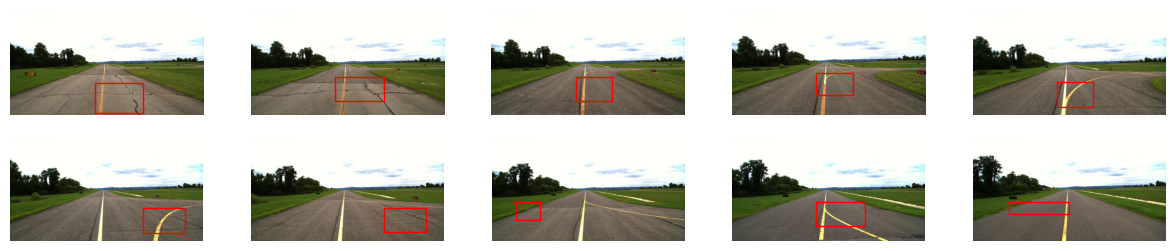

In [49]:
# Load in mosaic params (can be modified)
mosaic_params_KBCB = np.load('mosaic_params_KCBC.npy')

# Grab specified image points from local images 
gnav.grab_image_pts_tot(mosaic_params_KBCB)

plt.figure(figsize=(15,3))
gnav.plot_gnd_pts()

## Projections

In [50]:
## Generate projection of image sections 
# for i in range(gnav.im_num):
# for i in range(1): # TROUBLESHOOTING 1 IMAGE
# Just for the first image for now
for i in range(gnav.im_num):
    # Unit vectors in camera coords 
    pts_vec_c, pts_rgb_gnd = gnav.unit_vec_c(i)
    gnav.im_mosaic[i] = {'rgbc': pts_rgb_gnd}

    # Get transformation matrix that move from camera coords to world coords
    image_id = gnav.im_ids[i]
    homog_w2c, homog_c2w = gnav.get_pose_id(image_id,i)
    # print('Homogeneous transformation from world to camera \n', homog_c2w)
    # print('\n Homogeneous transformation from camera to world \n', homog_w2c)

    # Transform to world coords
    origin_c, pts_loc_w, pts_vec_w = gnav.unit_vec_tform(pts_vec_c, gnav.origin_w, homog_c2w)
    # print('\n New camera frame origin = ', origin_c)
    
    # Get new points 
    ranges, new_pts_w = gnav.pt_range(pts_vec_w, homog_c2w, origin_c, i)
    # print('\nNew Points \n', new_pts_w)

    # Transfer points to reference frame
    __, new_pts_r, pts_vec_r = gnav.unit_vec_tform(new_pts_w, gnav.origin_w, tform_ref_frame_pts)

    # Convert points to grayscale 
    gray_c = gnav.conv_to_gray(gnav.im_mosaic[i]['rgbc'],i)
    # print(gray_c)

    # Put new points and grayscale colors in image mosaic
    gnav.im_mosaic[i]['pts'] = new_pts_r
    gnav.im_mosaic[i]['color_g'] = gray_c
    
    print("\nDone image ", i)


Done image  0

Done image  1

Done image  2

Done image  3

Done image  4

Done image  5

Done image  6

Done image  7

Done image  8

Done image  9


In [51]:
# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1)

# If we just want to look at specific images
specified_clouds = np.array([0,1,2,3,4,5,7,8,9])

# for i in specified_clouds:
for i in range(gnav.im_num):
    print(i)
    cloud = o3d.geometry.PointCloud()
    cloud.points = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['pts'])
    cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['color_g'])
    vis.add_geometry(cloud)

scene_cloud = o3d.geometry.PointCloud()
scene_cloud.points = o3d.utility.Vector3dVector(scene_pts_ref)
scene_cloud.colors = o3d.utility.Vector3dVector(rgb_data)
vis.add_geometry(scene_cloud)

# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)

# Add necessary geometries to visualization 
vis.add_geometry(axis_origin)
# vis.add_geometry(ref_cloud)


# Run and destroy visualization 
vis.run()
vis.destroy_window()

0
1
2
3
4
5
6
7
8
9


# Single solution search 

In [ ]:
# SCALE for initial guess 
# scale = gnav.focal/39
scale = 120

# Avg guess for OLD IMAGES  
x = 345
# x = 0
y = 306
# y = 0
yaw = np.deg2rad(230)

In [213]:
# Implementing an initial guess for the local image 

imnum_curr = 9
ims = [imnum_curr]

# SCALE for initial guess 
# scale = gnav.focal/39
scale = 140

# Avg guess for OLD IMAGES  
x = 345
# x = 0
y = 302
# y = 0
yaw = np.deg2rad(231)


tform_guess = gnav.tform_create(x,y,0,0,0,yaw)
gnav.best_guess_tform = tform_guess
gnav.best_guess_scale = scale
# gnav.best_guess_scale_MD = s_mat # Multi-directional (MD)
# print(tform_guess)

ind_guess_curr = np.array([x, y, yaw, scale])


# NEW IMPLEMENTATION STRATEGY
# for i in range(gnav.im_num):
# Just for the first image for now
for i in ims:
    loc_im_pts = gnav.im_mosaic[i]['pts'].copy()
    # print(loc_im_pts)

    loc_im_pts[:, :2] *= scale # For SINGLE scale factor
    # loc_im_pts = loc_im_pts @ s_mat # For MULTI-DIRECTIONAL scale factor
    # Get new points 
    __, loc_im_pts_guess, loc_im_vec_guess = gnav.unit_vec_tform(loc_im_pts, gnav.origin_w, tform_guess)
    gnav.im_pts_best_guess[i] = {'pts': loc_im_pts_guess}
    # gnav.im_pts_best_guess[i]['tree'] = cKDTree(loc_im_pts_guess) # UNECESSARY 

    print("\nDone image ", i)


Done image  9


In [52]:
# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10)

# If we just want to SINGLE CLOUD 
cloud = o3d.geometry.PointCloud()
cloud.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[imnum_curr]['pts'])
cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[imnum_curr]['color_g'])
# cloud.paint_uniform_color([1.0,0.0,0.0])
vis.add_geometry(cloud)



# # If we just want to look at specific images
# specified_clouds = np.array([0,1,2,3,4,5,6,7])

# # for i in specified_clouds:
# for i in range(gnav.im_num):
#     print(i)
#     cloud = o3d.geometry.PointCloud()
#     cloud.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[i]['pts'])
#     cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['color_g'])
#     # cloud.paint_uniform_color([1.0,0.0,0.0])
#     vis.add_geometry(cloud)
    

# # Create point cloud for image points
# im0_cloud = o3d.geometry.PointCloud()
# im0_cloud.points = o3d.utility.Vector3dVector(gnav.im_mosaic[0]['pts'])
# im0_cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[0]['color_g'])

# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)

# Add necessary geometries to visualization 
vis.add_geometry(axis_origin)
vis.add_geometry(ref_cloud)


# Run and destroy visualization 
vis.run()
vis.destroy_window()

NameError: name 'imnum_curr' is not defined

In [215]:
print(yaw)

4.031710572106901


In [219]:
# #im 0: 331, 287, 4.03171057, 120
# #im 1: 331, 281, 4.03171057, 100
# #im 2: 331, 282, 4.03171057, 100
# #im 3: 368, 318, 4.04916386, 120
# #im 4: 331, 282, 4.03171057, 100
# #im 5: 302, 360, 4.27605667, 120
# #im 6: 361.5, 309.5, 4.04916386, 120
# #im 7: 355, 316, 4.04916386, 120
# #im 8: 350, 298, 4.03171057, 120
# #im 9: 345, 302, 4.03171057, 140

# # SCALE, yaw, x,y
# ind_params_KBCB = np.zeros((10,4))
# ind_params_KBCB[0] = [120, 4.03171057, 331, 287]
# ind_params_KBCB[1] = [100, 4.03171057, 331, 281]
# ind_params_KBCB[2] = [100, 4.03171057, 331, 282]
# ind_params_KBCB[3] = [120, 4.04916386, 368, 318]
# ind_params_KBCB[4] = [100, 4.03171057, 331, 282]
# ind_params_KBCB[5] = [120, 4.27605667, 302, 360]
# ind_params_KBCB[6] = [120, 4.04916386, 361.5, 309.5]
# ind_params_KBCB[7] = [120, 4.04916386, 355, 316]
# ind_params_KBCB[8] = [120, 4.03171057, 350, 298]
# ind_params_KBCB[9] = [140, 4.03171057, 345, 302]




In [220]:
# np.save('ind_params_KBCB_10IM.npy', ind_params_KBCB)

## Ground truth solutions 

In [24]:
# IMPLEMENTING 'TRUTH SOLUTION'
ind_params = np.load("ind_params_KBCB.npy")
gnav.im_num = len(ind_params) # SETTING IMAGE NUMBER (5)
# print(ind_params)
gnav.ind_params_truth = ind_params
gnav.implement_guess_ind(gnav.ind_params_truth)

In [25]:
# Create visualization
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Image mosaic with reference map (TRUTH)")

gnav.mosaic_w_ref_visualization(vis)

libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 80
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 80
pci id for fd 80: 8086:a7a0, driver iris
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
Using DRI3 for screen 0


# Remaining steps for error modeling pipeline 
- [x] Divide into micropatches
- [x] SSD process for micropatches
- [x] Micropatch distribution analysis
- [x] ERROR DISTB - softmax
    - [x] SSD process for inidividual images
    - [x] Full patch softmax
    - [x] Finding P_i
    - [x] Plot softmax results
- [x] ERROR DISTB - micropatches
    - [x] Blur 2d MP errors
    - [x] Continuous pdf from mixture model
    - [x] Discrete distribution sampling
    - [x] Watershed to GT
    - [x] Plot results
- [ ] Full plot comparison
- [ ] Experiment alternative SSD metrics

### Divide each patch into micropatches

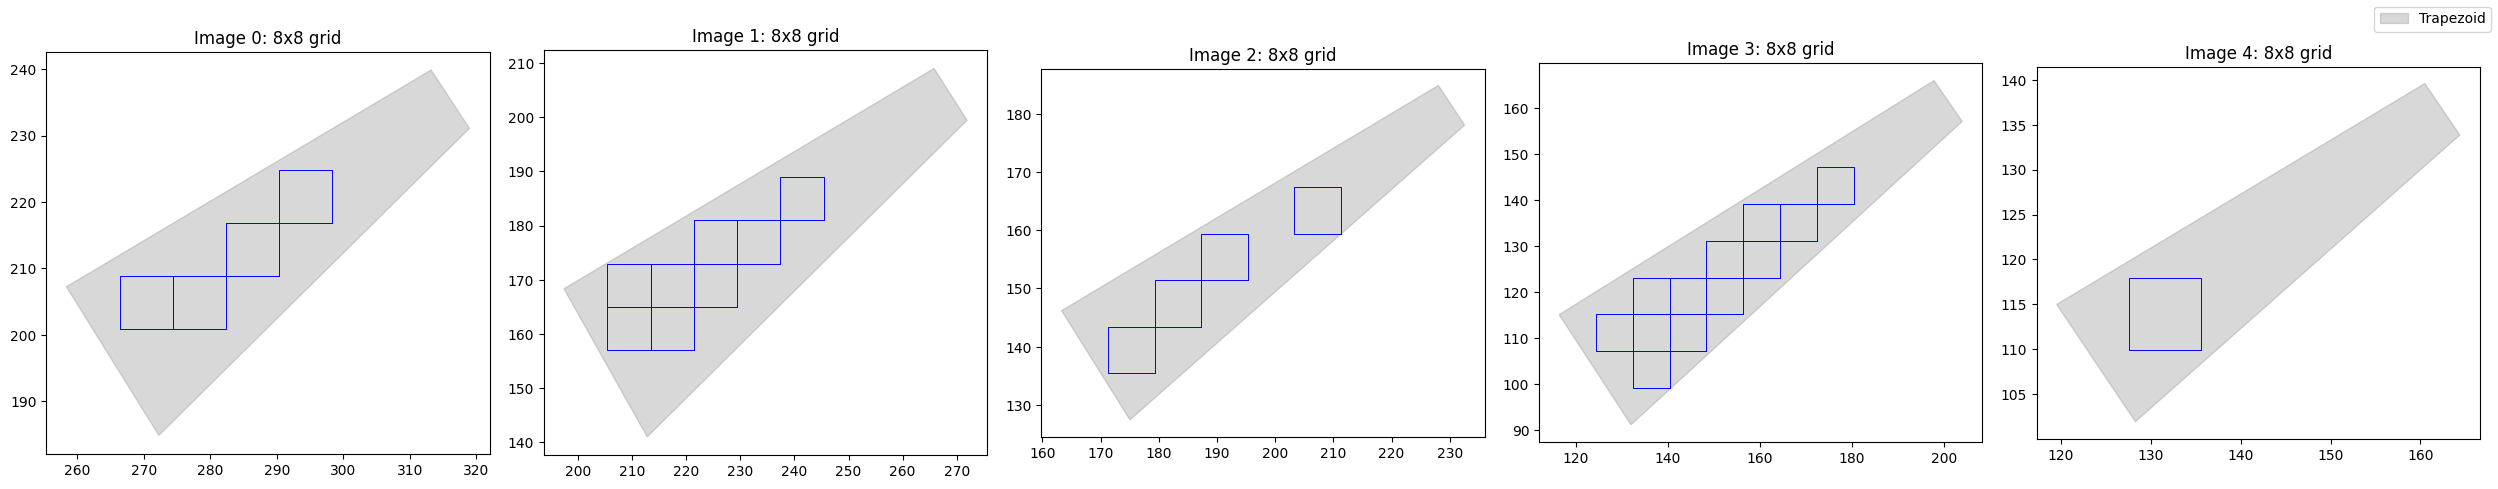

In [26]:
n = 8
micro_ps = gnav.micropatch_division(n)
gnav.micro_ps_local = copy.deepcopy(gnav.micro_ps) # KEEPING ORIGINAL, LOCAL IS WHAT WE EDIT
gnav.plot_traps_w_microps(n)

## Plotting the micropatches

In [27]:
# VISUAL CHECK OF MICROPATCHES
# Check that the points are at least proper

# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10)
vis.add_geometry(axis_origin)

# Add image patches
# for i in range(len(gnav.images_dict)):
# for i in range(2):
#     cloud = o3d.geometry.PointCloud()
#     cloud.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[i]['pts'])
#     cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['color_g'])
#     vis.add_geometry(cloud)


# Create point cloud for image points
img_spec = np.array([3])
for i in img_spec:
    for j in range(len(micro_ps[i])):
        # print(j)
        cloud_micro = o3d.geometry.PointCloud()
        cloud_micro.points = o3d.utility.Vector3dVector(micro_ps[i][j]['pts'])
        # cloud_micro.paint_uniform_color([.75, 0.001*j, 0.002*j])
        cloud_micro.colors = o3d.utility.Vector3dVector(micro_ps[i][j]['color_g'])
        vis.add_geometry(cloud_micro)



# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)
vis.add_geometry(ref_cloud)

# Run and destroy visualization 
vis.run()
vis.destroy_window()

libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 81
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 81
pci id for fd 81: 8086:a7a0, driver iris
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
Using DRI3 for screen 0


### SSD process for micropatches

In [28]:
ssds_curr_micro = [{} for _ in range(len(gnav.images_dict))]
gnav.ssds_curr_micro = [{} for _ in range(len(gnav.images_dict))]

In [29]:
# Loop through images and patches
n_ssd = 5

# for imnum in range(gnav.im_num):
#     for mp in range(len(gnav.micro_ps[imnum])):
#         ssds = gnav.ssd_nxn_micro(n_ssd, imnum, mp)
#         gnav.ssds_curr_micro[imnum][mp] = ssds
#     print(f'Done image {imnum}')

In [30]:
# # Save data as pickle 
# fn = 'KBCB_ssd_8x8_5n_T_5IMG.pkl'
# with open(fn, 'wb') as f:
#     pickle.dump(gnav.ssds_curr_micro, f)

In [31]:
# Import pickle data structure so we can SAVE SOME TIME
# Load
# with open('KBCB_ssd_8x8_5n_T_5IMG.pkl', 'rb') as f:
with open('KBCB_ssd_8x8_5n_T_NORM_5IMG.pkl', 'rb') as f:
    ssds_curr_micro_pkl = pickle.load(f)

In [32]:
# # SANITY CHECK 
# for imnum in range(gnav.im_num):
#     for mp in range(len(gnav.micro_ps[imnum])):
#         diff = gnav.ssds_curr_micro[imnum][mp] - ssds_curr_micro_pkl[imnum][mp]
#         print("DIFF", diff)

In [33]:
gnav.ssds_curr_micro = ssds_curr_micro_pkl # Assign to prev calculated values

### Minimum SSD and patch distribution

In [34]:
gnav.distb_vecs = [{} for _ in range(gnav.im_num)]
gnav.distb_pts = [{} for _ in range(gnav.im_num)]

# Grab correction vectors for each micro-patch
n_ssd = 5
for imnum in range(gnav.im_num):
    cor_vecs, points = gnav.dy_from_ssd_micro(n_ssd, imnum)
    gnav.distb_vecs[imnum] = cor_vecs
    gnav.distb_pts[imnum] = points

Done image 0
Done image 1
Done image 2
Done image 3
Done image 4


### Micropatch distribution analysis and plotter class

In [35]:
mpa = microp_distb(gnav, n, n_ssd, t = 1/12) # Alter threshold to t=1/10 if needed
mdb_plotter = microp_distb_plotter(gnav, mpa, n, n_ssd)

In [36]:
# Microp mean and var
mpa.calc_mean_var()

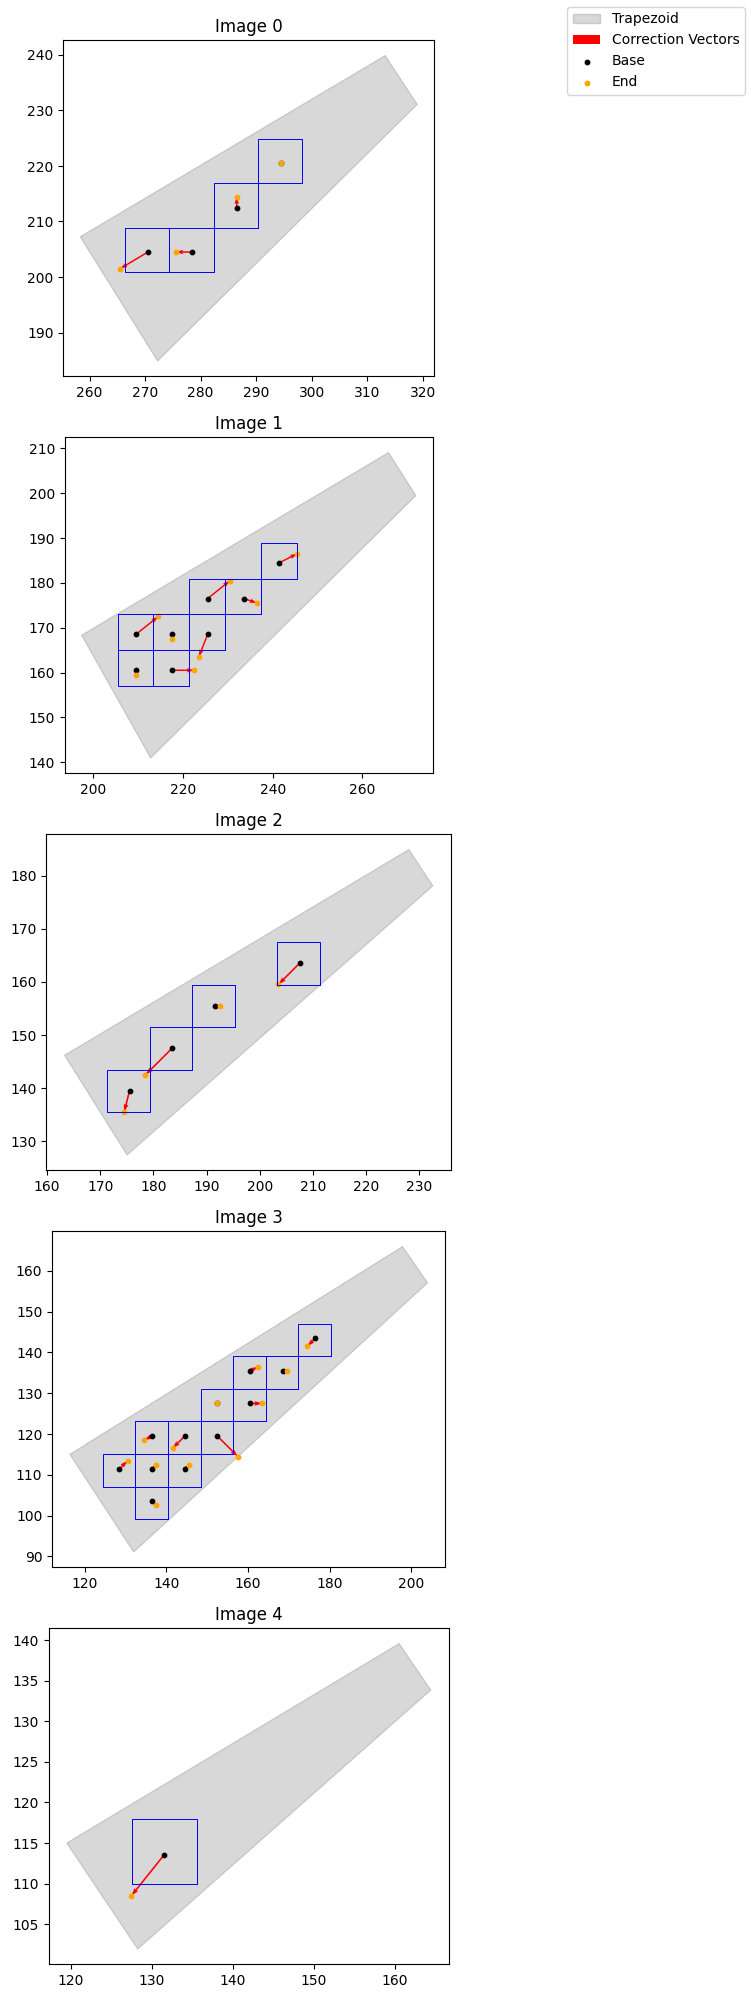

In [37]:
%matplotlib inline
mdb_plotter.plot_microps_w_corVecs()

### Softmax Function for SSD-Based Confidence (FULL PATCH)

Given scores $s_1, s_2, \ldots, s_n$, the softmax function converts them into probabilities:

$$
p_i = \frac{\exp(s_i)}{\sum_j \exp(s_j)}
$$

Softmax: Larger scores receive exponentially more weight.

In [38]:
# Through each patch and micro-patch, generate probability distb
mpa.prob_distb_FP = [{} for _ in range(gnav.im_num)]
mpa.ssds_curr_SM = [{} for _ in range(gnav.im_num)]
mpa.ssds_curr_SM_ORIG = [{} for _ in range(gnav.im_num)]
maxp = 0
# for imnum in range(gnav.im_num):
#     # Grab ssds - FOR FULL PATCH 
#     ssds = gnav.ssd_nxn(n_ssd, imnum)
#     ssds_norm = gnav.ssd_nxn_NORM(n_ssd, imnum)
#     mpa.ssds_curr_SM[imnum] = ssds_norm # CHANGED TO NORMALIZED VERSION INSTEAD OF 'ssds'
#     mpa.ssds_curr_SM_ORIG[imnum] = ssds

In [39]:
# # Save SSDs for runtime help 
# # Save data as pickle 
# fn = 'KBCB_ssd_curr_SM_NORM_5IMG.pkl'
# with open(fn, 'wb') as f:
#     pickle.dump(mpa.ssds_curr_SM, f)

In [40]:
# Import pickle data structure so we do not have to run again
# Load
with open('KBCB_ssd_curr_SM_NORM_5IMG.pkl', 'rb') as f:
# with open('KBCB_ssd_curr_SM_5IMG.pkl', 'rb') as f:
    ssds_curr_SM_pkl = pickle.load(f)

# # Sanity check 
# for imnum in range(gnav.im_num):
#     ssds1 = mpa.ssds_curr_SM[imnum]
#     ssds2 = ssds_curr_SM_pkl[imnum]
#     print(ssds1 - ssds2)

In [41]:
# Set to prev calculated
mpa.ssds_curr_SM = ssds_curr_SM_pkl
gnav.ssds_curr_SM = ssds_curr_SM_pkl

### SSD Surface Plots

In [42]:
# SSD Verification 
%matplotlib qt
im_check = 0
ssds = mpa.ssds_curr_SM[im_check]

mdb_plotter.ssd_surface_plots(ssds, im_check, n_ssd)#, method='probs')
mdb_plotter.ssd_surface_plots

BEST SHIFT for image 0: 2 -4


libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 87
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 87
pci id for fd 87: 8086:a7a0, driver iris
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
Using DRI3 for screen 0


<bound method microp_distb_plotter.ssd_surface_plots of <distb_plotting_utils_VTTI.microp_distb_plotter object at 0x7bbcb81f6fa0>>

### Full patch softmax

In [43]:
# Softmax distribution for each FULL patch - generates mpa.prob_distb_FP
mpa.FP_softmax()
# print(mpa.prob_distb_FP[0]['probs'])

In [44]:
# Surface plot visualization 
%matplotlib qt
# %matplotlib inline
imnum = 0
probs = mpa.prob_distb_FP[imnum]['probs']
mdb_plotter.ssd_surface_plots(probs, imnum, n_ssd, method='probs')

Highest probability shift for image 0: 2 -4


### Finding P_i for FULL PATCH 

In [45]:
# Set ground truth
p = mpa.im_num
gt = [0,0]
idrow, idcol = gt[0] + n_ssd, gt[1] + n_ssd
Pi_p = np.zeros((p))
cdf = np.zeros((p))
l_total = (n_ssd*2 + 1)**2
print("ID of row and col for P_GT:", idrow, idcol)
# Determine P_i for each image 
for imnum in range(mpa.im_num):
# for imnum in range(1):
    probs = mpa.prob_distb_FP[imnum]['probs']
    pgt = probs[idrow, idcol]
    print(f"\nIMAGE {imnum} ")
    # print("Probabilities\n", probs)
    # print("\nProbability of ground truth:", pgt)
    mask = probs > pgt
    print("\nMask of probabilities:\n",mask)
    probs_p_ind = np.argwhere(probs > pgt)
    # print("\nProbs over PGT (indices):\n", probs_p_ind)
    probs_p = probs[mask]
    l_probs = len(probs_p)
    print(f"\nProbs over PGT, length {l_probs}:\n", probs_p)
    P_i = np.sum(probs_p)
    print("\nP_i:", P_i)
    print("\nCDF:", l_probs/l_total)
    Pi_p[imnum] = P_i
    cdf[imnum] = l_probs / l_total

print("\nFINAL P_i's: \n", Pi_p)

ID of row and col for P_GT: 5 5

IMAGE 0 

Mask of probabilities:
 [[False False  True  True  True False False False False False False]
 [False False False  True  True False False False False False False]
 [ True False False False  True  True False False False False False]
 [ True False False False  True  True  True False False False False]
 [ True  True False False False  True  True False False False False]
 [ True  True  True False False False  True  True False False False]
 [ True  True  True  True False False  True  True  True False False]
 [ True  True  True  True  True False False  True  True False False]
 [ True  True  True  True  True False False False  True  True False]
 [ True  True  True  True  True  True False False False  True False]
 [ True  True  True  True  True  True False False False  True  True]]

Probs over PGT, length 57:
 [0.01075567 0.01666693 0.00808307 0.01324733 0.01501023 0.00863709
 0.0153299  0.01355139 0.01094644 0.00885282 0.01785968 0.01086168
 0.013904 

In [46]:
# PLOT 
Pi_ind_p = np.argsort(Pi_p)
# print(Pi_ind_p)
Pi_p_sorted = Pi_p[Pi_ind_p]
cdf_sorted = cdf[Pi_ind_p]

N = len(Pi_p)
cdf_new = np.arange(0,N)/N
cdf_new = np.arange(1,N+1)/N
print(cdf_new)
print(Pi_p_sorted)




# ---- Plot ----
plt.figure(figsize=(6, 5))
# OLD
# plt.plot(Pi_p_sorted, cdf_sorted, linewidth=2, label="Empirical CDF of $P_i$")
# plt.scatter(Pi_p_sorted, cdf_sorted, c='blue')
# NEW
plt.plot(Pi_p_sorted, cdf_new, linewidth=2, label="Empirical CDF of $P_i$")
plt.scatter(Pi_p_sorted, cdf_new, c='blue')
plt.plot([0, 1], [0, 1], "--", linewidth=2, label="Reference: $y=x$")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("$P_i$: Predicted CDF")
plt.ylabel("CDF")
plt.title("Empirical CDF of $P_i$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[0.2 0.4 0.6 0.8 1. ]
[0.         0.25199139 0.4762821  0.63019523 0.77785513]


# Micropatch Calibration Analysis

In [47]:
# Micropatch distribution plots
# Plot distribution vectors 
# %matplotlib inline
mdb_plotter.plot_distb_vecs(mpa.distb_vecs, mpa.full_mp_mean_var)

In [48]:
# Probability distribution generated FOR the full patch BY the micropatch process 
mpa.prob_distb_MP = [{} for i in range(mpa.im_num)]

In [49]:
def cont_pdf_gblur(x, distb_vecs, sigma_pix):
    assert distb_vecs.ndim == 2 and distb_vecs.shape[1] == 2
    cov = np.eye(2) * (sigma_pix**2)
    vals = [multivariate_normal.pdf(x, mean=mu, cov = cov) for mu in distb_vecs]
    return np.mean(vals)

In [50]:
# Define variables
n_ssd = 5 # SSD full shift 
sigma_pix = 3 # Gaussian blur param
GT_pos = np.array([0,0]) # Position of ground truth
Pi_p_microp = np.zeros((mpa.im_num)) # eCDF probabilities
step = 1 # Grid size 
steps_TEST = [.05, 1, 25, .5, 1] 
Pi_p_microp_GRID_TEST = []
shifts = np.arange(-n_ssd, n_ssd+step, step) 
print(f'Shifts: {shifts}')
N = len(shifts)


# print(GT_pos.shape)
for imnum in range(mpa.im_num):
    print(f"IMAGE: {imnum}\n")
    distb_vecs_im = mpa.distb_vecs[imnum]
    # LOOP OVER SSD 
    # ssds_prob = np.zeros((2*n_ssd + 1, 2*n_ssd + 1))
    ssds_prob = np.zeros((N,N))
    count = 0
    for i, xshift in enumerate(shifts):
        for j, yshift in enumerate(shifts):
            count +=1
            shift = np.array([xshift, yshift])
            # print("SSD shift:", xshift, yshift)
            p_x = cont_pdf_gblur(shift, distb_vecs_im, sigma_pix)
            # print("P_x:", p_x)
            # ssds_prob[xind,yind] = p_x
            ssds_prob[i,j] = p_x

    # Normalize and place probabilities in dict and 
    # print(f"Discrete probabilites for image {imnum}: \n{ssds_prob}")
    sum_probs = np.sum(ssds_prob)
    # print("SUM of probabilities:", sum_probs)
    norm_probs = ssds_prob / sum_probs
    mpa.prob_distb_MP[imnum]['probs'] = norm_probs
    # print("Normalized probabilities:", norm_probs)
    # print(f"Sum of normalized probs (should be 1): {np.sum(norm_probs)}")

    # Watershed for gt
    ix = np.argmin(np.abs(shifts - GT_pos[0]))
    iy = np.argmin(np.abs(shifts - GT_pos[1]))
    # pgt = norm_probs[n_ssd, n_ssd] # Ground truth probability
    pgt = norm_probs[ix,iy]
    # print(f'Ground truth probability indices: {ix,iy}')
    print(f'Ground truth probability: {pgt}')
    mask = norm_probs >= pgt
    print(f"MASK:\n{mask}")
    probs_over_gt = norm_probs[mask]
    l_probs = len(probs_over_gt)
    print(f"\nProbs over PGT, length {l_probs}:\n", np.round(probs_over_gt,4))
    P_i = np.sum(probs_over_gt)
    print('\nP_i: %.3f' % P_i)
    Pi_p_microp[imnum] = P_i

print(f"\nFINAL P_i's:\n{Pi_p_microp}")
Pi_p_microp_INITIAL = Pi_p_microp


Shifts: [-5 -4 -3 -2 -1  0  1  2  3  4  5]
IMAGE: 0

Ground truth probability: 0.015682772148815107
MASK:
[[False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False  True False False False False False]
 [False False False False  True  True  True False False False False]
 [False False False False False  True  True False False False False]
 [False False False False False  True  True False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]
 [False False False False False False False False False False False]]

Probs over PGT, length 8:
 [0.0158 0.0161 0.0169 0.0163 0.0169 0.0166 0.0157 0.0157]

P_i: 0.130
IMAGE: 1

Ground truth probability: 

In [51]:
# Surface plot visualization 
%matplotlib qt
# %matplotlib inline
imnum = 3
# probs = mpa.prob_distb_FP[imnum]['probs']
probs = mpa.prob_distb_MP[imnum]['probs']
mdb_plotter.ssd_surface_plots(probs, imnum, n_ssd, method='probs')

Highest probability shift for image 3: 1 0


In [52]:
# PLOT 
N1 = len(Pi_p)
Pi_p_sorted = np.sort(Pi_p)
cdf1 = np.arange(1,N1+1)/N1
# cdf1 = np.arange(0,N1)/N1

# SECOND PLOT 
N2 = len(Pi_p_microp_INITIAL)
Pi_p_microp_sorted = np.sort(Pi_p_microp_INITIAL)
cdf2 = np.arange(1,N2+1)/N2
# cdf2 = np.arange(0,N2)/N2
print(Pi_p_microp_sorted)
print(f"Micropatch PDF probabilities: \n{np.round(Pi_p_microp_sorted,3)}")
# cdf2 = np.arange(0,N2)/N2

# ---- Plot ----
plt.figure(figsize=(6, 5))
# NEW
plt.plot(Pi_p_sorted, cdf1, linewidth=2, label="eCDF of $P_i$ (Softmax)")
plt.scatter(Pi_p_sorted, cdf1, c='blue')
plt.plot(Pi_p_microp_sorted, cdf2, linewidth=2, label="eCDF of $P_i$ (micropatches)")
plt.scatter(Pi_p_microp_sorted, cdf2, c='orange')
plt.plot([0, 1], [0, 1], "--", linewidth=2, label="Reference: $y=x$")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("$P_i$: PDF")
plt.ylabel("CDF")
plt.title("Empirical CDF of $P_i$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[0.03325732 0.13002694 0.40137068 0.55479318 0.93547056]
Micropatch PDF probabilities: 
[0.033 0.13  0.401 0.555 0.935]


In [ ]:
# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10)

# If we just want to look at specific images
specified_clouds = np.array([0])

# change = np.array([[5,4,0],[4,3,0],[3,2,0],[2,1,0],[1,0,0],[0,-1,0]])
# change = np.array([[5,-5,0]])
# # for i in range(gnav.im_num):
# for i in change:
#     print(i)
#     cloud = o3d.geometry.PointCloud()
#     cloud.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[0]['pts']+i)
#     cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[0]['color_g'])
#     vis.add_geometry(cloud)

cloud_CHECK = o3d.geometry.PointCloud()
cloud_CHECK.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[3]['pts'])#+change)
cloud_CHECK.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[3]['color_g'])
vis.add_geometry(cloud_CHECK)

scene_cloud = o3d.geometry.PointCloud()
scene_cloud.points = o3d.utility.Vector3dVector(scene_pts_ref)
scene_cloud.colors = o3d.utility.Vector3dVector(rgb_data)
# vis.add_geometry(scene_cloud)

# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)

# Add necessary geometries to visualization 
vis.add_geometry(axis_origin)
vis.add_geometry(ref_cloud)


# Run and destroy visualization 
vis.run()
vis.destroy_window()